# Scaling Laws: 모델 크기의 법칙 - 실습 코드 1: Scaling Laws 실험: 파라미터 수 vs Loss 시뮬레이션

- Tutorial ID: `expand-scaling-laws`
- Tutorial: Scaling Laws: 모델 크기의 법칙
- Section ID: `expand-scaling-laws-code-1`
- Section: 실습 코드 1: Scaling Laws 실험: 파라미터 수 vs Loss 시뮬레이션

이 노트북에서는 "모델을 키우면 성능이 얼마나 좋아질까?"라는 질문에 답한 두 편의 유명한 논문 —
Kaplan et al. (2020)의 *Scaling Laws for Neural Language Models* 와, Hoffmann et al. (2022)의
*Training Compute-Optimal Large Language Models* (일명 "Chinchilla 논문") — 의 핵심 공식을
파이썬 코드로 직접 재현합니다. 실제로 신경망을 학습시키지는 않지만, 논문이 실험으로 찾아낸 공식에
숫자를 대입하고 그래프로 그려보면서 "파라미터 수 · 데이터 양 · 연산량(Compute)"과 "Loss" 사이의
관계를 몸으로 느껴보는 것이 목표입니다.

In [1]:
# ============================================================
# 코드 읽는 법 — 실습 코드 1: Scaling Laws 실험: 파라미터 수 vs Loss 시뮬레이션
#
# 이 노트북은 "정답 코드를 한 번 실행하고 끝"이 아니라, Scaling Law 논문에 나오는 수식이
# 실제로 숫자·그래프로 어떻게 나타나는지 한 단계씩 눈으로 확인하기 위한 실습 노트입니다.
#
# 학습 목표:
#   1) "Scaling Law(스케일링 법칙)"이 무엇이고, 왜 "거듭제곱 법칙(power law)"이라 부르는지 이해한다
#   2) 파라미터 수(N)·데이터 양(D)이 늘어날 때 Loss가 어떻게 줄어드는지 Kaplan et al. (2020) 공식으로
#      직접 계산하고 시각화한다
#   3) 로그-로그(log-log) 그래프에서는 왜 거듭제곱 법칙이 "직선"으로 보이는지 확인한다
#   4) 노이즈가 섞인 가짜 실험 데이터를 만들고, 그 데이터만 가지고 거꾸로 Scaling Law 지수(alpha)를
#      "추정"해 본다 → 실제 연구자들이 여러 번 학습을 돌려 얻은 결과에 곡선을 "피팅(fitting)"하는
#      과정을 축소판으로 체험한다
#   5) Chinchilla 논문의 L(N, D) 공식을 이해하고, 정해진 연산량(Compute) 안에서 "모델을 얼마나 크게,
#      데이터를 얼마나 많이" 써야 Loss가 최소가 되는지 계산한다
#   6) GPT-3, Gopher, Chinchilla 같은 실제 모델이 "이론상 최적" 대비 얼마나 과소 학습(undertrained)
#      되어 있었는지 비교해 본다
#
# 읽는 순서:
#   1) 각 코드 블록 바로 위의 마크다운 설명을 먼저 읽고, "지금 무엇을 계산하려는지" 그림을 그려봅니다.
#   2) 코드 안의 주석(#)은 수식의 각 기호(N, D, C, alpha, beta ...)가 무엇을 의미하는지 짚어줍니다.
#   3) print()로 찍히는 숫자와 그래프의 모양을 함께 보면서, "숫자가 커지면 그래프가 어떻게 움직이는지"
#      확인합니다.
#   4) 마지막 "직접 해보기" 섹션에서 값을 바꿔가며 스스로 실험해 봅니다.
#
# 주의:
#   - 이 노트북은 실제로 신경망을 학습시키지 않습니다. 논문에서 "이미 학습을 통해 얻은 공식"을
#     가져와 숫자로 계산·시각화하는 것이 목적입니다. (그래서 제목이 "시뮬레이션"입니다.)
#   - numpy, matplotlib만 있으면 실행되며, 별도의 GPU나 딥러닝 프레임워크는 필요하지 않습니다.
# ============================================================

## 0. 들어가기 전에 — Scaling Law가 뭔가요?

딥러닝, 특히 언어 모델(LLM)을 만들 때 우리는 크게 세 가지를 조절할 수 있습니다.

| 기호 | 의미 | 쉬운 설명 |
|---|---|---|
| **N** | 파라미터 수 (모델 크기) | 모델 안에 있는 "학습 가능한 숫자(가중치)"의 개수. 클수록 더 복잡한 패턴을 담을 수 있음 |
| **D** | 데이터 양 | 학습에 사용하는 텍스트의 토큰(단어 조각) 개수 |
| **C** | 연산량 (Compute) | 모델을 학습시키는 데 드는 총 계산량. 보통 FLOPs(총 부동소수점 연산 횟수) 단위로 측정 |
| **L** | Loss | 모델이 다음 토큰을 얼마나 못 맞히는지 나타내는 점수. **작을수록 모델이 더 똑똑하다**는 뜻 |

**"Scaling Law(스케일링 법칙)"** 란, N·D·C를 늘렸을 때 L이 얼마나, 그리고 어떤 "모양"으로 줄어드는지
설명하는 경험적(실험으로 발견한) 수학 공식입니다. 신기하게도 연구자들이 모델 크기를 수십~수백 배씩
바꿔가며 실험해 보니, Loss는 아래와 같은 **거듭제곱 법칙(power law)** 형태를 따른다는 사실이
발견되었습니다.

$$L(X) \approx \left(\frac{X_c}{X}\right)^{\alpha}$$

말로 풀면 이렇습니다. *"X(파라미터 수든 데이터 양이든)가 늘어날수록 Loss는 계속 줄어들지만, 그
줄어드는 속도는 X가 커질수록 점점 느려진다."* 이런 관계를 로그-로그(log-log) 그래프로 그리면
"직선"으로 나타나는데(1장 뒤에서 직접 확인합니다), 이 성질을 이용하면 적은 실험만으로도 "모델을
100배 더 키우면 Loss가 대략 얼마가 될지"를 미리 예측할 수 있습니다. 이것이 바로 OpenAI, DeepMind
같은 곳에서 막대한 비용을 들여 초대형 모델을 학습시키기 전에, 작은 모델로 먼저 실험해서 성능을
예측하는 방법입니다.

이 노트북에서는 아래 두 논문의 핵심 공식을 코드로 그대로 재현합니다.

1. **Kaplan et al., "Scaling Laws for Neural Language Models" (2020, OpenAI)**
   — N만 늘렸을 때, D만 늘렸을 때 각각 Loss가 어떻게 줄어드는지에 대한 공식
2. **Hoffmann et al., "Training Compute-Optimal Large Language Models" (2022, DeepMind, 일명
   "Chinchilla 논문")**
   — 정해진 연산량(C) 안에서 N과 D를 각각 얼마씩 늘려야 Loss가 최소가 되는지에 대한 공식

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 주피터 노트북 안에서 그래프가 셀 바로 아래에 바로 보이도록 설정하는 매직 명령어입니다.
%matplotlib inline

# ── 한글 폰트 설정 ──
# matplotlib의 기본 폰트는 한글을 지원하지 않아서, 아무 설정 없이 그래프에 한글을 쓰면
# 글자가 네모(□)로 깨져 보입니다. 아래 코드는 시스템에 설치된 한글 지원 폰트를 자동으로 찾아 등록합니다.
for _path in fm.findSystemFonts():
    if any(k in _path.lower() for k in ["nanum", "malgun", "cjk", "notosanskr", "gothic"]):
        fm.fontManager.addfont(_path)

_candidate_fonts = ["Malgun Gothic", "AppleGothic", "NanumGothic",
                     "Noto Sans CJK KR", "Noto Sans KR", "Noto Sans CJK JP"]
_installed_fonts = {f.name for f in fm.fontManager.ttflist}
_korean_font = next((f for f in _candidate_fonts if f in _installed_fonts), None)

if _korean_font:
    plt.rcParams["font.family"] = _korean_font
    print(f"한글 폰트 설정 완료: {_korean_font}")
else:
    print("한글 폰트를 찾지 못했습니다. 그래프의 한글이 네모(□)로 보일 수 있습니다.")
    print("  Windows는 보통 '맑은 고딕'이 기본 내장되어 있고, Mac은 'AppleGothic',")
    print("  Linux는 'sudo apt install fonts-nanum' 등으로 나눔고딕을 설치할 수 있습니다.")

plt.rcParams["axes.unicode_minus"] = False   # 마이너스 부호(-)가 한글 폰트에서 깨지는 것 방지

# ── 그래프 기본 스타일 (필수는 아니지만 보기 편하도록) ──
plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print(f"환경 준비 완료 (numpy {np.__version__}, matplotlib {matplotlib.__version__})")

한글 폰트 설정 완료: Noto Sans CJK JP
환경 준비 완료 (numpy 2.4.4, matplotlib 3.10.8)


## 1. Kaplan Scaling Law ① — 파라미터 수(N) vs Loss

Kaplan et al. (2020)은 데이터와 연산량이 충분할 때(즉, 파라미터 수만 "병목"일 때), 파라미터 수 N과
Loss L 사이에 아래와 같은 관계가 있다는 것을 대규모 실험으로 확인했습니다.

$$L(N) = \left(\frac{N_c}{N}\right)^{\alpha_N}$$

- **N** : 모델의 (임베딩을 제외한) 파라미터 수
- **N_c ≈ 8.8 × 10¹³** : 논문에서 실험 데이터에 곡선을 맞춰(fitting) 찾아낸 상수. "이 정도 파라미터
  수를 가지면 Loss가 1이 된다"는 기준점 역할을 하는 숫자일 뿐, 그 자체로 특별한 의미가 있는 크기는
  아닙니다.
- **α_N ≈ 0.076** : N이 커질 때 Loss가 줄어드는 "속도"를 나타내는 지수. 값이 작을수록 파라미터를
  늘려도 Loss가 더디게 줄어든다는 뜻입니다.

**감을 잡기 위한 예시** — N을 10배로 늘리면 Loss는 몇 배가 될까요?

$$\frac{L(10N)}{L(N)} = \left(\frac{N}{10N}\right)^{\alpha_N} = 10^{-\alpha_N} = 10^{-0.076} \approx 0.84$$

즉, **파라미터를 10배 늘리면 Loss는 약 84% 수준(16% 감소)** 으로만 줄어듭니다. 처음엔 작은 개선처럼
보이지만, 언어 모델의 Loss 스케일에서는 이 정도의 감소도 체감 성능 차이를 꽤 크게 만듭니다. 아래
코드 셀에서 이 예시를 직접 계산해서 검증해 봅니다.

In [3]:
# ── Kaplan et al. (2020) 논문에서 가져온 상수 ──
# 이 상수들은 "실제 학습 결과에 곡선을 맞춰서(curve fitting)" 얻은 값입니다.
# 즉 이론적으로 유도된 숫자가 아니라, 수백~수천 번의 학습 실험을 해 보니 이 값이 가장 잘 맞았다는 뜻입니다.
N_c = 8.8e13      # 파라미터 스케일 상수 (단위: 파라미터 개수)
alpha_N = 0.076   # 파라미터 수 증가에 대한 Loss 감소 지수


def L_of_N(N):
    """
    파라미터 수 N만 놓고 봤을 때, Kaplan Scaling Law가 예측하는 Loss.
        L(N) = (N_c / N) ** alpha_N
    데이터 양과 연산량은 충분하다고 가정한, "모델 크기만 병목인 상황"의 예측치입니다.
    """
    return (N_c / N) ** alpha_N


# 1000만(1e7) ~ 1000억(1e11) 파라미터까지, "로그 스케일"로 균등하게 50개 지점을 뽑습니다.
# np.logspace(7, 11, 50) : 10**7 부터 10**11 사이를 로그 기준으로 50등분합니다.
#   (뒤로 갈수록 값 사이의 '차이'는 크게 벌어지지만, 로그값 기준으로는 일정한 간격입니다)
param_counts = np.logspace(7, 11, 50)
loss_by_params = L_of_N(param_counts)

print("=== Kaplan Scaling Law: 파라미터 수(N)별 예측 Loss ===")
for n in [1e7, 1e8, 1e9, 1e10, 1e11]:
    print(f"  N = {n:>12,.0f}  ({n:.0e}) ->  L(N) = {L_of_N(n):.4f}")

# 위 마크다운 셀에서 손으로 계산했던 "N을 10배 늘리면 Loss는 몇 배가 되는가"를 코드로도 검증해 봅니다.
ratio = L_of_N(1e10) / L_of_N(1e9)
print(f"\n검증: N을 10배(1e9 -> 1e10) 늘렸을 때 Loss 비율 = {ratio:.4f}")
print(f"      이론값 10**(-alpha_N)                    = {10 ** (-alpha_N):.4f}  (거의 같아야 정상)")

=== Kaplan Scaling Law: 파라미터 수(N)별 예측 Loss ===
  N =   10,000,000  (1e+07) ->  L(N) = 3.3712
  N =  100,000,000  (1e+08) ->  L(N) = 2.8300
  N = 1,000,000,000  (1e+09) ->  L(N) = 2.3756
  N = 10,000,000,000  (1e+10) ->  L(N) = 1.9943
  N = 100,000,000,000  (1e+11) ->  L(N) = 1.6741

검증: N을 10배(1e9 -> 1e10) 늘렸을 때 Loss 비율 = 0.8395
      이론값 10**(-alpha_N)                    = 0.8395  (거의 같아야 정상)


### 그래프로 확인하기 — 왜 "로그-로그" 스케일을 쓸까요?

같은 데이터를 **일반 스케일**과 **로그-로그(log-log) 스케일** 두 가지로 그려서 비교해 보겠습니다.

- **일반 스케일**: x축·y축 눈금이 1, 2, 3 ... 처럼 "일정한 간격"으로 커집니다.
- **로그-로그 스케일**: x축·y축 눈금이 1, 10, 100, 1000 ... 처럼 "10배씩" 커집니다.

거듭제곱 법칙(power law) 관계에 있는 데이터는 로그-로그 스케일에서 보면 **완벽한 직선**이 됩니다.
양변에 로그를 취하면

$$\log L = \alpha_N \log N_c - \alpha_N \log N$$

으로, $\log N$에 대한 **1차 함수(직선)** 형태가 되기 때문입니다. 이 성질 덕분에 연구자들은 "그래프가
직선이면 power law가 맞다"고 눈으로 바로 확인할 수 있고, 직선의 기울기만 재면 지수(α)를 구할 수
있습니다. (3장에서 이 방법으로 직접 α를 추정해 봅니다.)

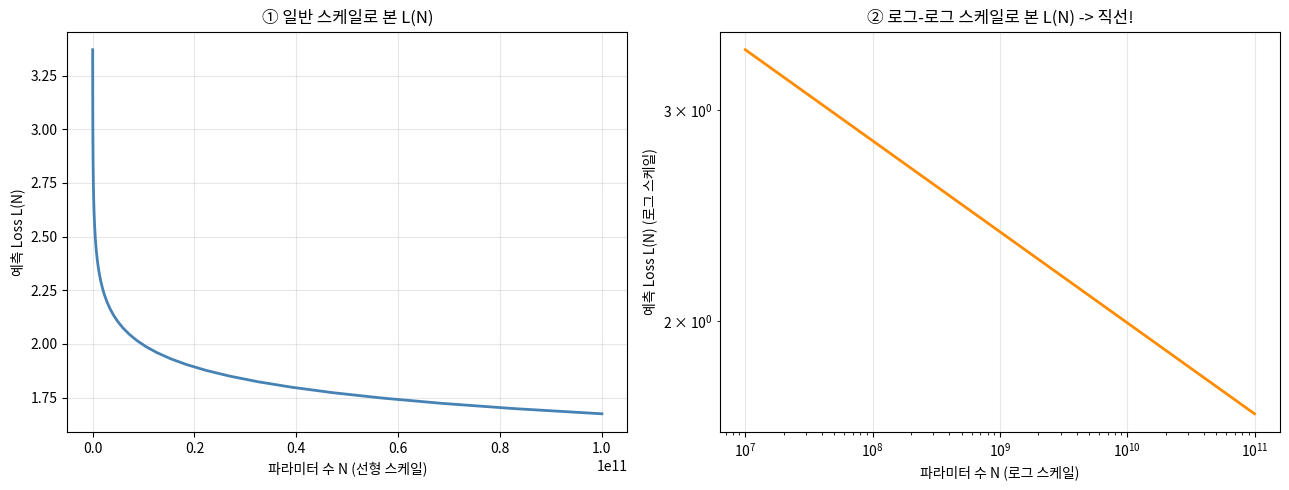

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 왼쪽: 일반(선형) 스케일 -- 처음엔 급격히 떨어지다 점점 완만해지는 곡선으로 보입니다.
axes[0].plot(param_counts, loss_by_params, color="steelblue", linewidth=2)
axes[0].set_xlabel("파라미터 수 N (선형 스케일)")
axes[0].set_ylabel("예측 Loss L(N)")
axes[0].set_title("① 일반 스케일로 본 L(N)")

# 오른쪽: 로그-로그 스케일 -- 완벽한 직선으로 보입니다. (거듭제곱 법칙의 특징)
axes[1].plot(param_counts, loss_by_params, color="darkorange", linewidth=2)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("파라미터 수 N (로그 스케일)")
axes[1].set_ylabel("예측 Loss L(N) (로그 스케일)")
axes[1].set_title("② 로그-로그 스케일로 본 L(N) -> 직선!")

plt.tight_layout()
plt.show()

## 2. Kaplan Scaling Law ② — 데이터 양(D) vs Loss

똑같은 논리가 데이터 양 D에도 그대로 적용됩니다. 이번엔 모델 크기와 연산량이 충분하다고 가정하고,
데이터 양만 바꿔가며 Loss가 어떻게 변하는지 봅니다.

$$L(D) = \left(\frac{D_c}{D}\right)^{\alpha_D}$$

- **D** : 학습에 사용한 토큰(token, 단어 조각) 개수
- **D_c ≈ 5.4 × 10¹³**, **α_D ≈ 0.095** : N과 마찬가지로 논문에서 실험적으로 찾아낸 상수

α_D(0.095)가 α_N(0.076)보다 **더 크다**는 점이 흥미롭습니다. 지수가 클수록 그만큼 늘렸을 때 Loss가
더 빨리 줄어든다는 뜻이므로, "같은 비율만큼 늘린다면 데이터를 늘리는 쪽이 파라미터를 늘리는 것보다
Loss 감소에 조금 더 효과적"이라는 힌트를 줍니다. (이 힌트가 나중에 5~6장의 Chinchilla 논문에서 왜
중요해지는지 다시 다룹니다.)

=== Kaplan Scaling Law: 데이터 양(D)별 예측 Loss ===
  D =   1,000,000,000  (1e+09) ->  L(D) = 2.8156
  D =  10,000,000,000  (1e+10) ->  L(D) = 2.2624
  D = 100,000,000,000  (1e+11) ->  L(D) = 1.8179
  D = 1,000,000,000,000  (1e+12) ->  L(D) = 1.4608
  D = 10,000,000,000,000  (1e+13) ->  L(D) = 1.1738


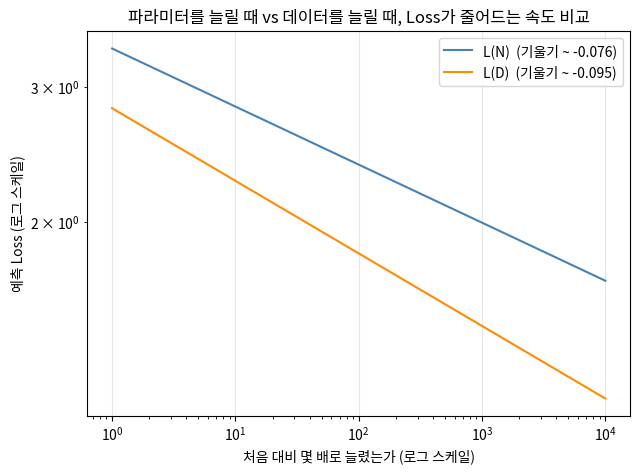


alpha_D(0.095) > alpha_N(0.076) 이므로, 그래프에서 주황색 선 L(D)이 파란색 선 L(N)보다 더 가파르게 떨어지는 것을 확인할 수 있습니다.


In [5]:
# -- D_c, alpha_D 상수 정의 (역시 논문에서 실험적으로 찾아낸 값) --
D_c = 5.4e13     # 데이터 스케일 상수 (단위: 토큰 개수)
alpha_D = 0.095  # 데이터 양 증가에 대한 Loss 감소 지수


def L_of_D(D):
    """데이터 양 D만 놓고 봤을 때, Kaplan Scaling Law가 예측하는 Loss. (모델 크기·연산량은 충분하다고 가정)"""
    return (D_c / D) ** alpha_D


data_counts = np.logspace(9, 13, 50)   # 10억(1e9) ~ 10조(1e13) 토큰
loss_by_data = L_of_D(data_counts)

print("=== Kaplan Scaling Law: 데이터 양(D)별 예측 Loss ===")
for d in [1e9, 1e10, 1e11, 1e12, 1e13]:
    print(f"  D = {d:>15,.0f}  ({d:.0e}) ->  L(D) = {L_of_D(d):.4f}")

# N을 늘렸을 때와 D를 늘렸을 때, Loss가 줄어드는 '기울기'를 한 그래프에서 비교합니다.
# 두 곡선의 x축 단위(파라미터 개수 vs 토큰 개수)가 다르므로, 각자의 시작값으로 나누어
# "처음 대비 몇 배로 늘렸는가"라는 공통 기준으로 정규화했습니다.
plt.figure(figsize=(7, 5))
plt.plot(param_counts / param_counts[0], loss_by_params,
         label=f"L(N)  (기울기 ~ -{alpha_N})", color="steelblue")
plt.plot(data_counts / data_counts[0], loss_by_data,
         label=f"L(D)  (기울기 ~ -{alpha_D})", color="darkorange")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("처음 대비 몇 배로 늘렸는가 (로그 스케일)")
plt.ylabel("예측 Loss (로그 스케일)")
plt.title("파라미터를 늘릴 때 vs 데이터를 늘릴 때, Loss가 줄어드는 속도 비교")
plt.legend()
plt.show()

print(f"\nalpha_D({alpha_D}) > alpha_N({alpha_N}) 이므로, 그래프에서 주황색 선 L(D)이 파란색 선 L(N)보다 "
      f"더 가파르게 떨어지는 것을 확인할 수 있습니다.")

## 3. 미니 시뮬레이션 — "진짜 실험처럼" 노이즈가 낀 데이터에서 α 추정해보기

지금까지는 논문에 이미 나와 있는 상수(N_c, α_N)를 가져다 쓰기만 했습니다. 하지만 실제 연구자들은 이
상수를 어떻게 알아냈을까요? 정답은 "미리 알고 시작한 게 아니라, 여러 크기의 모델을 직접 학습시켜서
얻은 (N, Loss) 데이터에 곡선을 맞춰(curve fitting) 거꾸로 추정"한 것입니다.

또한 실제 학습에는 항상 **노이즈(noise)** 가 낍니다. 같은 크기의 모델이라도 가중치 초기값, 데이터가
섞이는 순서 등에 따라 Loss가 아주 조금씩 다르게 나옵니다. 이번 절에서는 이 상황을 흉내 내 봅니다.

**순서**
1. "진짜" α_N = 0.076을 알고 있다고 가정하고, 여러 N에 대해 이론적인 Loss를 계산합니다.
2. 여기에 무작위 노이즈를 살짝 섞어서 "마치 실제로 여러 번 학습시켜서 얻은 것처럼" 보이는 가짜 데이터를
   만듭니다.
3. 이 노이즈 낀 데이터"만" 가지고, α_N을 모른다고 가정한 채 로그-로그 스케일에서 직선을 맞춰(선형
   회귀) α_N을 추정합니다.
4. 추정한 값이 우리가 처음에 정해둔 "진짜" 값과 얼마나 비슷한지 확인합니다.

In [6]:
# 재현 가능한 결과를 위해 랜덤 시드를 고정합니다.
# (시드를 고정하면 이 셀을 몇 번 다시 실행해도 매번 똑같은 '무작위' 값이 나옵니다)
rng = np.random.default_rng(seed=42)

# 1) "진짜" 값이라고 가정하는 파라미터. (아래 3~4단계에서는 이 값을 모른다고 가정하고 추정을 시도합니다)
true_alpha_N = 0.076
true_N_c = 8.8e13

# 2) 실험에 사용할 모델 크기들. 실제 연구에서는 계산 비용 때문에 아주 많은 지점을 실험하지 못하므로,
#    앞의 그래프(50개)보다 훨씬 적은 15개 지점만 "학습시켜 봤다"고 가정합니다.
experiment_N = np.logspace(7, 10.5, 15)          # 1000만 ~ 약 316억, 15개 모델
true_loss = (true_N_c / experiment_N) ** true_alpha_N

# 3) 노이즈 추가: 실제 학습 결과는 이론값 주변에서 %(곱셈) 단위로 조금씩 흔들립니다.
#    예) 이론값이 3.00이어도 실제로는 2.94~3.06 사이 어딘가로 나올 수 있음 (표준편차 2%로 가정)
noise_level = 0.02
noisy_loss = true_loss * rng.normal(loc=1.0, scale=noise_level, size=experiment_N.shape)

print("=== 시뮬레이션한 '실험 결과' (15개 중 앞 5개만 표시) ===")
for n, l_true, l_noisy in list(zip(experiment_N, true_loss, noisy_loss))[:5]:
    print(f"  N={n:.2e} ->  이론 Loss={l_true:.4f}   노이즈 낀 '실제' Loss={l_noisy:.4f}")

# 4) 이제부터는 noisy_loss "만" 알고 있다고 가정하고, alpha_N을 거꾸로 추정합니다.
#    양변에 로그를 취하면:  log(L) = -alpha_N * log(N) + alpha_N * log(N_c)
#    이는 log(N)에 대한 1차식(직선) y = 기울기*x + 절편 형태이므로, 선형 회귀로 기울기·절편을 구할 수 있습니다.
#    np.polyfit(x, y, 1) 은 y ~= a*x + b 를 만족하는 (a, b)를 최소제곱법으로 찾아줍니다.
log_N = np.log10(experiment_N)
log_L = np.log10(noisy_loss)
slope, intercept = np.polyfit(log_N, log_L, 1)

estimated_alpha_N = -slope                              # 기울기 = -alpha_N 이므로 부호를 뒤집습니다.
estimated_N_c = 10 ** (intercept / estimated_alpha_N)    # 절편 = alpha_N * log10(N_c) 를 거꾸로 풀어냅니다.

print("\n=== 노이즈 낀 데이터만 가지고 역으로 추정한 결과 ===")
print(f"  추정된 alpha_N = {estimated_alpha_N:.4f}   (진짜 값: {true_alpha_N})")
print(f"  추정된 N_c     = {estimated_N_c:.3e}   (진짜 값: {true_N_c:.3e})")
print("  -> 노이즈가 섞여 있었는데도, 15개의 점만으로 원래 지수에 꽤 가깝게 도달했습니다!")

=== 시뮬레이션한 '실험 결과' (15개 중 앞 5개만 표시) ===
  N=1.00e+07 ->  이론 Loss=3.3712   노이즈 낀 '실제' Loss=3.3917
  N=1.78e+07 ->  이론 Loss=3.2269   노이즈 낀 '실제' Loss=3.1597
  N=3.16e+07 ->  이론 Loss=3.0887   노이즈 낀 '실제' Loss=3.1351
  N=5.62e+07 ->  이론 Loss=2.9565   노이즈 낀 '실제' Loss=3.0121
  N=1.00e+08 ->  이론 Loss=2.8300   노이즈 낀 '실제' Loss=2.7195

=== 노이즈 낀 데이터만 가지고 역으로 추정한 결과 ===
  추정된 alpha_N = 0.0736   (진짜 값: 0.076)
  추정된 N_c     = 1.299e+14   (진짜 값: 8.800e+13)
  -> 노이즈가 섞여 있었는데도, 15개의 점만으로 원래 지수에 꽤 가깝게 도달했습니다!


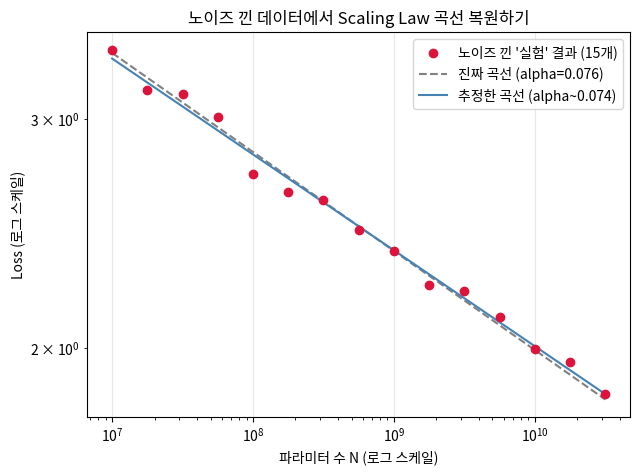

In [7]:
plt.figure(figsize=(7, 5))

# 노이즈 낀 '실험' 데이터 포인트 (실제로 15번 학습시켜 얻었다고 가정한 값들)
plt.scatter(experiment_N, noisy_loss, color="crimson", zorder=3, label="노이즈 낀 '실험' 결과 (15개)")

# 우리가 정해둔 '진짜' 곡선 (매끄럽게 그리기 위해 점 200개로 다시 계산)
dense_N = np.logspace(7, 10.5, 200)
plt.plot(dense_N, (true_N_c / dense_N) ** true_alpha_N,
         "--", color="gray", label=f"진짜 곡선 (alpha={true_alpha_N})")

# 노이즈 낀 데이터만 보고 우리가 '추정'해 낸 곡선
plt.plot(dense_N, (estimated_N_c / dense_N) ** estimated_alpha_N,
         color="steelblue", label=f"추정한 곡선 (alpha~{estimated_alpha_N:.3f})")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("파라미터 수 N (로그 스케일)")
plt.ylabel("Loss (로그 스케일)")
plt.title("노이즈 낀 데이터에서 Scaling Law 곡선 복원하기")
plt.legend()
plt.show()

## 4. N과 D를 함께 봐야 하는 이유

지금까지 본 L(N), L(D) 공식에는 중요한 전제가 하나 숨어 있습니다. **"다른 하나는 충분하다고 가정"**
한다는 점입니다. L(N)을 계산할 때는 "데이터는 충분하다"고 가정했고, L(D)를 계산할 때는 "모델은
충분히 크다"고 가정했습니다.

하지만 현실에서 우리에게 주어지는 것은 대개 **정해진 연산량(Compute) 예산 C** 뿐입니다. 예산이
정해져 있으면 N과 D는 서로 **트레이드오프(trade-off)** 관계가 됩니다 — 모델을 더 크게 만들수록(N↑),
같은 예산 안에서 학습에 쓸 수 있는 데이터는 줄어듭니다(D↓). 그 반대도 마찬가지입니다. 트랜스포머
모델을 학습시킬 때 필요한 연산량은 대략 아래처럼 근사할 수 있습니다.

$$C \approx 6ND$$

토큰 하나를 순전파(forward)하는 데 파라미터당 약 2번의 연산이, 역전파(backward)에는 그 두 배인 약
4번의 연산이 필요해서 토큰 하나당 총 약 6N번의 연산이 든다고 근사하고, 여기에 전체 토큰 수 D를
곱하면 총 연산량 C ≈ 6ND (단위: FLOPs)가 됩니다.

그래서 진짜 궁금한 질문은 이것입니다.

> **"연산량 예산 C가 정해져 있을 때, N과 D를 각각 얼마로 정해야 Loss가 최소가 될까?"**

이 질문에 답한 것이 바로 2022년 DeepMind의 **Chinchilla 논문**입니다.

## 5. Chinchilla Loss 공식 — L(N, D)

Chinchilla 논문(Hoffmann et al., 2022)은 N과 D를 **동시에** 고려하는 아래 Loss 공식을 실험 데이터에
맞춰(fitting) 제안했습니다. (논문에서는 이를 "Approach 3"이라고 부릅니다.)

$$L(N, D) = E + \frac{A}{N^{\alpha}} + \frac{B}{D^{\beta}}$$

세 항목이 각각 무엇을 의미하는지 하나씩 보면:

| 항 | 의미 |
|---|---|
| **E ≈ 1.69** | **줄일 수 없는 Loss (irreducible loss)**. 모델을 아무리 키우고 데이터를 아무리 늘려도 이 값 밑으로는 내려가지 않습니다. 자연어 자체가 가진 "예측 불가능성(엔트로피)"의 한계라고 이해하면 됩니다. |
| **A / N^α** | **모델 크기 때문에 생기는 손해**. N이 커질수록(모델이 커질수록) 이 항은 0에 가까워집니다. (A≈406.4, α≈0.34) |
| **B / D^β** | **데이터 양 때문에 생기는 손해**. D가 커질수록(데이터가 많아질수록) 이 항은 0에 가까워집니다. (B≈410.7, β≈0.28) |

즉 "이상적인 Loss(E)"에서 시작해서, "모델이 완벽히 크지 않아서 생기는 손해"와 "데이터가 완벽히
많지 않아서 생기는 손해"를 더한 것이 실제 Loss라는 뜻입니다. N과 D를 각각 무한히 키우면 두 손해
항이 모두 0에 가까워져 L → E 로 수렴합니다.

> 💡 **참고**: 위 A, B, α, β 값은 논문 원본(Approach 3)에서 보고된 값입니다. 이후 다른 연구팀(Epoch AI,
> 2024)이 논문의 그래프에서 데이터를 다시 추출해 재분석한 결과, 다소 다른 값(A≈482, B≈2085, β≈0.37
> 등)을 얻기도 했습니다. 이는 Scaling Law의 상수들이 "고정된 물리 법칙"이 아니라, **주어진 데이터·
> 아키텍처·학습 방식에서 통계적으로 추정한 값**이며, 재분석에 따라 조금씩 달라질 수 있다는 것을 보여주는
> 좋은 사례입니다. 이 노트북에서는 가장 널리 인용되는 원본 논문 값을 사용합니다.

In [8]:
# -- Chinchilla 논문(Hoffmann et al., 2022, Approach 3)의 fitted 상수 --
E = 1.69      # 줄일 수 없는 Loss (자연어 자체가 갖는 예측 불가능성의 한계, 단위: nats)
A = 406.4     # 모델 크기 항의 계수
B = 410.7     # 데이터 양 항의 계수
alpha = 0.34  # 모델 크기에 대한 지수
beta = 0.28   # 데이터 양에 대한 지수


def chinchilla_loss(N, D):
    """
    Chinchilla 논문의 L(N, D) = E + A/N**alpha + B/D**beta 공식.
    N: 파라미터 수, D: 학습 토큰 수
    """
    return E + A / (N ** alpha) + B / (D ** beta)


# 예시 1) 실제 Chinchilla 모델 스펙(70B 파라미터, 1.4조 토큰)의 예측 Loss
example_N, example_D = 70e9, 1.4e12
print(f"예시 1) N={example_N:.0e}, D={example_D:.1e}  ->  예측 Loss = {chinchilla_loss(example_N, example_D):.4f}")

# 예시 2) 파라미터 수는 그대로 두고, 데이터만 절반(700B 토큰)으로 줄이면?
half_D = example_D / 2
print(f"예시 2) N={example_N:.0e}, D={half_D:.0e} (데이터 절반)  ->  예측 Loss = {chinchilla_loss(example_N, half_D):.4f}")
print("        -> 모델 크기는 그대로인데 데이터를 절반만 쓰면 예측 Loss가 더 높아집니다 (더 나쁜 모델).")

# 예시 3) 반대로 데이터는 그대로 두고, 파라미터 수를 2배(140B)로 늘리면?
double_N = example_N * 2
print(f"예시 3) N={double_N:.1e} (파라미터 2배), D={example_D:.1e}  ->  예측 Loss = {chinchilla_loss(double_N, example_D):.4f}")

예시 1) N=7e+10, D=1.4e+12  ->  예측 Loss = 1.9366
예시 2) N=7e+10, D=7e+11 (데이터 절반)  ->  예측 Loss = 1.9716
        -> 모델 크기는 그대로인데 데이터를 절반만 쓰면 예측 Loss가 더 높아집니다 (더 나쁜 모델).
예시 3) N=1.4e+11 (파라미터 2배), D=1.4e+12  ->  예측 Loss = 1.9191


## 6. Chinchilla 최적점 구하기 — N_opt(C), D_opt(C)

이제 "연산량 예산 C가 주어졌을 때 Loss를 최소로 만드는 N과 D"를 구해보겠습니다. 수식으로 쓰면:

$$\min_{N,D} \; L(N,D) = E + \frac{A}{N^\alpha} + \frac{B}{D^\beta} \quad \text{단,} \quad C = 6ND \text{ 로 고정}$$

C = 6ND 라는 제약을 이용해 D = C/(6N) 을 L(N,D)에 대입하면 L은 N 하나만의 함수가 되고, 이를 N에
대해 미분해서 0으로 놓고 풀면 (자세한 미분 과정은 생략하고 결과만 사용합니다) 아래와 같이 **깔끔한
거듭제곱 형태의 해**가 나옵니다.

$$N_{opt}(C) = G \left(\frac{C}{6}\right)^{\frac{\beta}{\alpha+\beta}}, \qquad
D_{opt}(C) = G^{-1} \left(\frac{C}{6}\right)^{\frac{\alpha}{\alpha+\beta}}, \qquad
G = \left(\frac{\alpha A}{\beta B}\right)^{\frac{1}{\alpha+\beta}}$$

복잡해 보이지만 핵심만 추리면 이렇습니다.

- N_opt과 D_opt 모두 **C의 거듭제곱** 형태입니다 → C를 로그 스케일로 늘리면 N_opt, D_opt도 로그
  스케일에서 직선으로 늘어난다는 뜻입니다.
- 지수를 계산해 보면 β/(α+β) ≈ 0.28/0.62 ≈ **0.45**, α/(α+β) ≈ 0.34/0.62 ≈ **0.55** 로, 둘 다
  **0.5에 가깝습니다**. 이것이 바로 "Chinchilla 법칙: **연산량이 늘면 모델 크기도, 데이터도 거의
  비슷한 속도로(제곱근에 가깝게) 늘려야 한다**"는 유명한 결론의 근거입니다.
  (참고로 Kaplan et al.의 원래 결론은 이 지수가 한쪽으로 크게 치우쳐 있어서(N_opt ∝ C^0.73)
  "모델을 데이터보다 훨씬 더 크게 키워야 한다"는, Chinchilla와는 반대되는 조언이었습니다. Chinchilla
  논문이 더 정교한 실험으로 이 결론을 뒤집은 것입니다.)

In [9]:
def chinchilla_optimal(compute_budget):
    """
    주어진 연산량 예산(FLOPs)에서, Loss를 최소로 만드는 (N_opt, D_opt)을 계산합니다.

    유도 개요 (바로 위 마크다운 셀 참고):
      C = 6*N*D 라는 제약 아래 L(N,D) = E + A/N^alpha + B/D^beta 를 N에 대해 미분해 0으로 놓고 풀면,
      N_opt, D_opt이 모두 compute_budget의 거듭제곱(power) 형태로 깔끔하게 정리됩니다.
    """
    a = beta / (alpha + beta)    # N_opt ∝ C**a   (약 0.45)
    b = alpha / (alpha + beta)   # D_opt ∝ C**b   (약 0.55)

    # G는 N과 D 사이의 '균형점'을 결정하는 상수입니다.
    G = (alpha * A / (beta * B)) ** (1 / (alpha + beta))

    N_opt = G * (compute_budget / 6) ** a
    D_opt = (compute_budget / 6) ** b / G

    return N_opt, D_opt


print("=== Chinchilla 최적: 연산량(Compute)별 최적 모델/데이터 크기 ===")
for compute in [1e20, 1e21, 1e22, 1e23, 1e24]:
    n_opt, d_opt = chinchilla_optimal(compute)
    print(f"  C = {compute:.0e} FLOPs  ->  N_opt = {n_opt:.2e},  D_opt = {d_opt:.2e}"
          f"   (약 {n_opt/1e9:.1f}B 파라미터 / {d_opt/1e9:.0f}B 토큰, 비율 ~ {d_opt/n_opt:.0f}배)")

=== Chinchilla 최적: 연산량(Compute)별 최적 모델/데이터 크기 ===
  C = 1e+20 FLOPs  ->  N_opt = 6.45e+08,  D_opt = 2.58e+10   (약 0.6B 파라미터 / 26B 토큰, 비율 ~ 40배)
  C = 1e+21 FLOPs  ->  N_opt = 1.82e+09,  D_opt = 9.14e+10   (약 1.8B 파라미터 / 91B 토큰, 비율 ~ 50배)
  C = 1e+22 FLOPs  ->  N_opt = 5.16e+09,  D_opt = 3.23e+11   (약 5.2B 파라미터 / 323B 토큰, 비율 ~ 63배)
  C = 1e+23 FLOPs  ->  N_opt = 1.46e+10,  D_opt = 1.14e+12   (약 14.6B 파라미터 / 1142B 토큰, 비율 ~ 78배)
  C = 1e+24 FLOPs  ->  N_opt = 4.13e+10,  D_opt = 4.04e+12   (약 41.3B 파라미터 / 4036B 토큰, 비율 ~ 98배)


연산량 C가 10배씩 커질 때마다 위 출력의 "비율" 값이 조금씩 커지는 것을 볼 수 있습니다. N_opt과
D_opt의 지수(각각 약 0.45, 0.55)가 완전히 같지 않기 때문입니다.

참고로 흔히 알려진 **"토큰 수 ≈ 파라미터 수 × 20"** 이라는 경험칙은 사실 이 수식(Approach 3)이
아니라, 논문이 함께 제시한 다른 두 가지 추정 방법과 실제로 학습된 Chinchilla 70B 모델(1.4T 토큰)에서
나온 결과입니다. (5장에서 이야기했듯, Approach 3의 상수는 재분석에 따라 달라질 수 있는 추정치라는
점도 같이 기억해 두세요.) 정확한 숫자 자체보다는 "모델 크기와 데이터 양을 함께 늘려야 한다"는
방향성이 핵심입니다. 아래 7장에서 실제 모델들과 비교하며 이 부분을 다시 살펴봅니다.

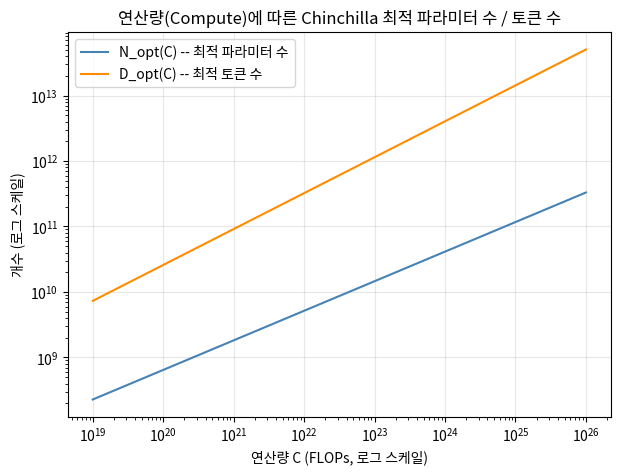

In [10]:
compute_range = np.logspace(19, 26, 100)
n_opts, d_opts = chinchilla_optimal(compute_range)

plt.figure(figsize=(7, 5))
plt.plot(compute_range, n_opts, label="N_opt(C) -- 최적 파라미터 수", color="steelblue")
plt.plot(compute_range, d_opts, label="D_opt(C) -- 최적 토큰 수", color="darkorange")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("연산량 C (FLOPs, 로그 스케일)")
plt.ylabel("개수 (로그 스케일)")
plt.title("연산량(Compute)에 따른 Chinchilla 최적 파라미터 수 / 토큰 수")
plt.legend()
plt.show()

## 7. 실제 모델들은 최적점에 얼마나 가까웠을까? — 과소 학습(Undertraining) 분석

Chinchilla 논문이 발표되기 전, GPT-3(2020)나 Gopher(2021) 같은 모델들은 "모델을 최대한 크게 키우고,
데이터는 상대적으로 적게" 학습시키는 경향이 있었습니다. (이는 Kaplan et al.의 원래 결론
N_opt ∝ C^0.73 — "모델을 데이터보다 훨씬 빠르게 키워라" — 을 따른 것이었습니다.)

아래에서는 GPT-3, Gopher, Chinchilla 세 모델의 **실제** (N, D)를 가져와서, 각 모델이 사용한 것과
**똑같은 연산량**을 앞서 만든 `chinchilla_optimal()` 함수에 넣었을 때 나오는 "이론상 최적" (N, D)와
비교해 봅니다.

In [11]:
# 실제로 공개된 세 모델의 파라미터 수(N)와 학습 토큰 수(D)
# (참고: Chinchilla 논문 Table 1에 나온, 논문 발표 당시를 대표하는 대형 언어 모델들입니다)
models = {
    "GPT-3 (2020)":      {"N": 175e9, "D": 300e9},
    "Gopher (2021)":     {"N": 280e9, "D": 300e9},
    "Chinchilla (2022)": {"N": 70e9,  "D": 1400e9},
}

print(f"{'모델':<20}{'실제 N':>10}{'실제 D':>12}{'실제 비율':>12}{'최적 N':>12}{'최적 D':>12}{'최적 비율':>12}")
print("-" * 90)

results = {}
for name, m in models.items():
    n_val, d_val = m["N"], m["D"]
    compute = 6 * n_val * d_val                    # 이 모델이 실제로 사용한 연산량(FLOPs)
    n_opt, d_opt = chinchilla_optimal(compute)      # 같은 연산량을 '최적'으로 배분했다면?

    actual_ratio = d_val / n_val
    optimal_ratio = d_opt / n_opt
    results[name] = {"N": n_val, "D": d_val, "N_opt": n_opt, "D_opt": d_opt}

    print(f"{name:<20}{n_val/1e9:>8.0f}B{d_val/1e9:>10.0f}B{actual_ratio:>10.1f}x"
          f"{n_opt/1e9:>10.1f}B{d_opt/1e9:>10.0f}B{optimal_ratio:>10.1f}x")

print("""
관찰:
  - GPT-3와 Gopher는 '실제 비율(D/N)'이 '최적 비율'보다 훨씬 작습니다.
    -> 모델 크기(N)에 비해 데이터(D)를 너무 적게 사용했다는 뜻으로, 이런 상태를 "과소 학습
       (undertrained)"되었다고 부릅니다. 같은 연산량으로 모델을 조금 줄이고 데이터를 늘렸다면
       더 낮은 Loss를 얻을 수 있었습니다.
  - Chinchilla는 앞의 두 모델보다 훨씬 더 많은 데이터를 사용해서, 실제 비율이 최적 비율에 더 가깝습니다.

주의:
  여기서 계산한 '최적'은 논문이 제시한 세 가지 추정 방법 중 하나(Approach 3, 파라미터 공식)를 따른
  값입니다. 논문은 이 외에도 두 가지 다른 방법을 더 사용했는데, 세 방법이 완전히 같은 숫자를
  내놓지는 않습니다. 그럼에도 "GPT-3·Gopher는 모델 크기 대비 데이터가 부족했다"는 방향성 자체는
  세 방법 모두 동일하게 가리키고 있습니다 -- 이것이 Chinchilla 논문의 핵심 메시지입니다.
""")

모델                        실제 N        실제 D       실제 비율        최적 N        최적 D       최적 비율
------------------------------------------------------------------------------------------
GPT-3 (2020)             175B       300B       1.7x      24.5B      2142B      87.4x
Gopher (2021)            280B       300B       1.1x      30.3B      2772B      91.5x
Chinchilla (2022)         70B      1400B      20.0x      32.5B      3016B      92.8x

관찰:
  - GPT-3와 Gopher는 '실제 비율(D/N)'이 '최적 비율'보다 훨씬 작습니다.
    -> 모델 크기(N)에 비해 데이터(D)를 너무 적게 사용했다는 뜻으로, 이런 상태를 "과소 학습
       (undertrained)"되었다고 부릅니다. 같은 연산량으로 모델을 조금 줄이고 데이터를 늘렸다면
       더 낮은 Loss를 얻을 수 있었습니다.
  - Chinchilla는 앞의 두 모델보다 훨씬 더 많은 데이터를 사용해서, 실제 비율이 최적 비율에 더 가깝습니다.

주의:
  여기서 계산한 '최적'은 논문이 제시한 세 가지 추정 방법 중 하나(Approach 3, 파라미터 공식)를 따른
  값입니다. 논문은 이 외에도 두 가지 다른 방법을 더 사용했는데, 세 방법이 완전히 같은 숫자를
  내놓지는 않습니다. 그럼에도 "GPT-3·Gopher는 모델 크기 대비 데이터가 부족했다"는 방향성 자체는
  세 방법 모두 동일하게 가리키고 있습니다 -- 이것이 Chinchilla 논문의 핵심 메시지입니다.



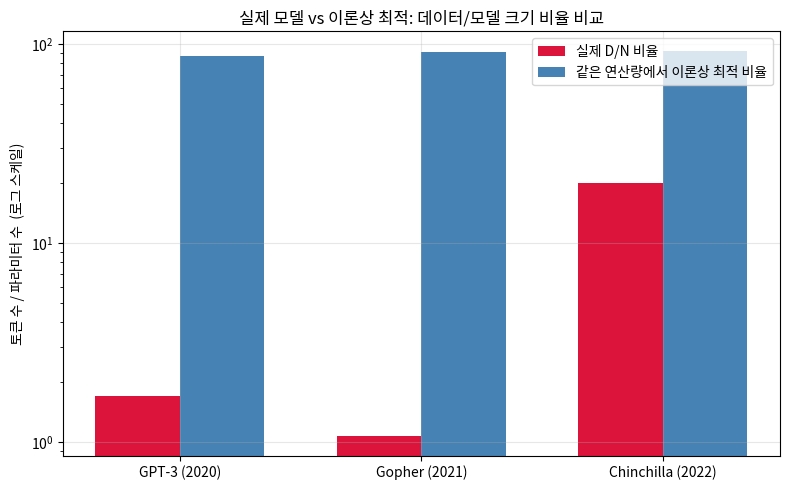

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

names = list(results.keys())
actual_ratios = [results[name]["D"] / results[name]["N"] for name in names]
optimal_ratios = [results[name]["D_opt"] / results[name]["N_opt"] for name in names]

x = np.arange(len(names))
width = 0.35

ax.bar(x - width / 2, actual_ratios, width, label="실제 D/N 비율", color="crimson")
ax.bar(x + width / 2, optimal_ratios, width, label="같은 연산량에서 이론상 최적 비율", color="steelblue")

ax.set_yscale("log")   # 비율 차이가 커서 로그 스케일로 봐야 비교하기 편합니다.
ax.set_ylabel("토큰 수 / 파라미터 수  (로그 스케일)")
ax.set_title("실제 모델 vs 이론상 최적: 데이터/모델 크기 비율 비교")
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.legend()
plt.tight_layout()
plt.show()

## 8. 직접 해보기

아래 아이디어들을 코드 셀에 직접 입력해 실험해 보세요. (새 코드 셀을 추가하려면 이 셀을 선택한 뒤
`b` 키를 누르면 됩니다.)

1. **나만의 모델 평가하기**: `chinchilla_loss(N, D)` 함수에 여러분이 궁금한 모델의 파라미터 수와
   토큰 수를 넣어 예측 Loss를 계산해 보세요. (예: LLaMA, Mistral 등 알고 있는 모델의 공개된 스펙을
   검색해서 넣어보기)
2. **연산량을 바꿔보기**: `chinchilla_optimal(compute_budget)`에 1e25, 1e26 같은 더 큰 값을 넣어보고,
   미래에 훨씬 큰 연산량을 쓸 수 있게 된다면 최적 모델 크기가 어느 정도일지 예측해 보세요.
3. **노이즈 크기를 바꿔보기**: 3장의 시뮬레이션에서 `noise_level`을 0.02에서 0.10, 0.20으로 늘려보고,
   노이즈가 커질수록 추정한 alpha_N이 진짜 값에서 얼마나 더 벗어나는지 관찰해 보세요. (실험 노이즈가
   클수록 적은 데이터 포인트만으로 정확한 Scaling Law를 추정하기가 어려워집니다.)
4. **실험 데이터 개수를 바꿔보기**: `experiment_N`을 만들 때 15개 대신 5개, 또는 40개로 바꿔보고,
   데이터 포인트가 적을 때/많을 때 추정 정확도가 어떻게 달라지는지 비교해 보세요.

## 정리

- **Scaling Law**는 "모델 크기(N), 데이터 양(D), 연산량(C)을 늘리면 Loss가 거듭제곱 법칙(power law)을
  따라 예측 가능하게 줄어든다"는 경험적 발견입니다.
- 로그-로그(log-log) 스케일에서 그리면 거듭제곱 법칙은 **직선**이 되고, 이 성질 덕분에 적은 실험만으로도
  큰 모델의 성능을 미리 추정할 수 있습니다.
- Kaplan et al. (2020)은 N과 D를 **따로** 보았을 때의 법칙 L(N), L(D)를 제시했습니다.
- Hoffmann et al. (2022, Chinchilla)은 N과 D를 **함께** 고려한 L(N,D) 공식과, 정해진 연산량 C 안에서
  Loss를 최소로 만드는 (N_opt, D_opt)를 구하는 공식을 제시했습니다.
- 그 결과, GPT-3·Gopher 같은 초기 대형 모델들은 모델 크기에 비해 데이터가 부족한 **"과소 학습
  (undertrained)"** 상태였다는 것이 밝혀졌고, 이후 LLM들은 데이터 양을 훨씬 더 중요하게 고려하도록
  학습 전략이 바뀌었습니다.
- Scaling Law의 상수들은 "절대 진리"가 아니라 **주어진 데이터와 실험 범위 안에서 추정한 값**이며,
  아키텍처·데이터 품질·학습 방식이 달라지면 상수도 달라질 수 있다는 점을 기억해 두세요.

**참고 문헌**
- Kaplan, J. et al. (2020). *Scaling Laws for Neural Language Models*. arXiv:2001.08361
- Hoffmann, J. et al. (2022). *Training Compute-Optimal Large Language Models*. arXiv:2203.15556